In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix, 
                             roc_curve, roc_auc_score, accuracy_score,
                             precision_score, recall_score, f1_score)
import warnings
warnings.filterwarnings('ignore')

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


In [2]:
df = pd.read_csv('/Users/stevennn/cardiac-strainlabs/training models/dataset-3.csv')
print("=" * 60)
print("DATA LOADED SUCCESSFULLY")
print("=" * 60)
print(f"\nDataset Shape: {df.shape}")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
print(f"\nColumn Names:\n{df.columns.tolist()}")
print(f"\nFirst few rows:")
print(df.head())

DATA LOADED SUCCESSFULLY

Dataset Shape: (5000, 8)
Rows: 5000, Columns: 8

Column Names:
['Sl_no', 'Age', 'BMI', 'PROBNP', 'EF', 'GLS', 'NFATC3', 'Risk_Level']

First few rows:
   Sl_no  Age  BMI  PROBNP  EF  GLS  NFATC3 Risk_Level
0      1   28   27     277  50  -20    0.89     Normal
1      2   34   19    1149  43  -15    1.48       High
2      3   22   19    1338  32  -18    1.14       High
3      4   23   33    1547  52  -12    2.03       High
4      5   67   22    1559  46  -28    1.30   Moderate


In [3]:
# Data Exploration

print("=" * 60)
print("DATA EXPLORATION")
print("=" * 60)

# Basic info
print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nBasic Statistics:")
print(df.describe())

# Check for duplicates
duplicates = df.duplicated().sum()
print(f"\nDuplicate rows: {duplicates}")

DATA EXPLORATION

Data Types:
Sl_no           int64
Age             int64
BMI             int64
PROBNP          int64
EF              int64
GLS             int64
NFATC3        float64
Risk_Level     object
dtype: object

Missing Values:
Sl_no         0
Age           0
BMI           0
PROBNP        0
EF            0
GLS           0
NFATC3        0
Risk_Level    0
dtype: int64

Basic Statistics:
             Sl_no          Age          BMI      PROBNP           EF  \
count  5000.000000  5000.000000  5000.000000  5000.00000  5000.000000   
mean   2500.500000    48.627800    26.029800   918.58800    49.348200   
std    1443.520003    18.148254     4.882508   506.37942    11.513499   
min       1.000000    18.000000    18.000000    50.00000    30.000000   
25%    1250.750000    33.000000    22.000000   486.00000    39.000000   
50%    2500.500000    48.000000    26.000000   921.00000    49.000000   
75%    3750.250000    65.000000    30.000000  1364.25000    59.000000   
max    5000.000000 

TARGET VARIABLE ANALYSIS

Target Variable: Risk_Level

Class Distribution:
Risk_Level
High        2295
Moderate    1976
Normal       729
Name: count, dtype: int64

Class Proportions:
Risk_Level
High        45.90
Moderate    39.52
Normal      14.58
Name: proportion, dtype: float64


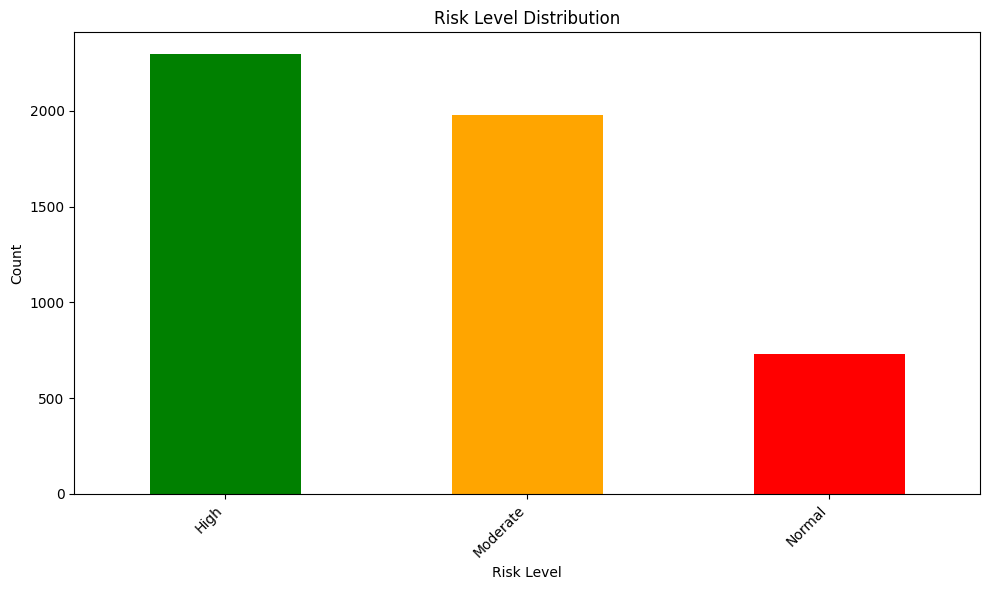


✓ Target variable defined


In [4]:
# Define Target Variable
target_col = 'Risk_Level' 
feature_cols = [col for col in df.columns if col not in [target_col, 'Sl_no']] 
X = df[feature_cols]
y = df[target_col]

print("=" * 60)
print("TARGET VARIABLE ANALYSIS")
print("=" * 60)
print(f"\nTarget Variable: {target_col}")
print(f"\nClass Distribution:")
print(y.value_counts())
print(f"\nClass Proportions:")
print(y.value_counts(normalize=True) * 100)

# Visualize class distribution with appropriate colors for 3 classes
plt.figure(figsize=(10, 6))
colors = ['green', 'orange', 'red']  # Normal=green, Moderate=orange, High=red
y.value_counts().plot(kind='bar', color=colors)
plt.title('Risk Level Distribution')
plt.xlabel('Risk Level')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')  # Rotate labels for better readability
plt.tight_layout()
plt.savefig('target_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Target variable defined")

FEATURE CORRELATION WITH TARGET

Risk Level Encoding:
  Risk_Level  Encoded
0     Normal        0
4   Moderate        1
1       High        2


Feature Correlations with Target:
NFATC3    0.413254
PROBNP    0.406646
GLS       0.186121
BMI       0.003760
Age      -0.168382
EF       -0.408946
dtype: float64


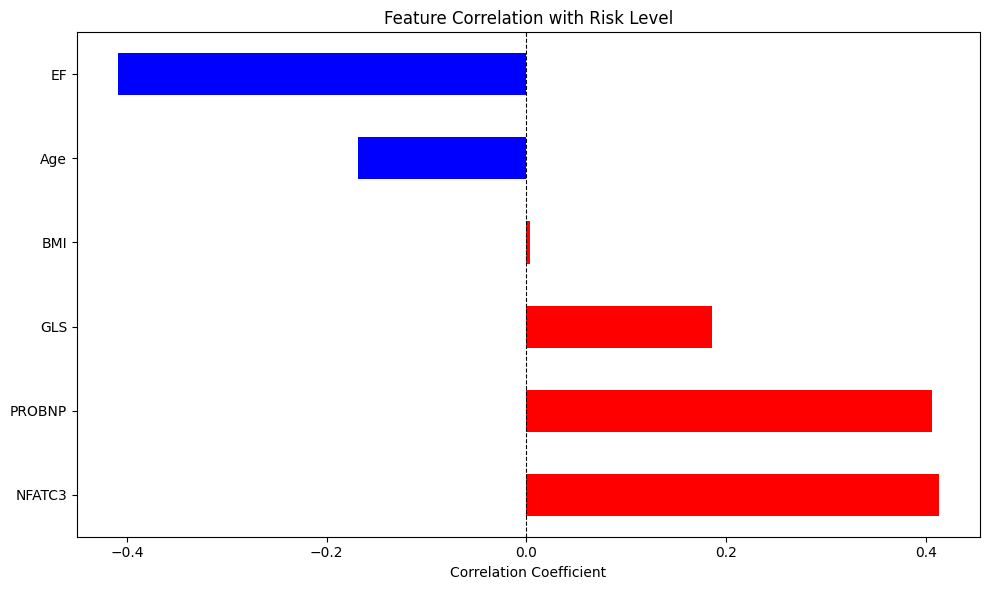

'\n# Correlation heatmap\nplt.figure(figsize=(12, 8))\n# Create a temporary dataframe with numeric target for correlation\ndf_numeric = X.copy()\ndf_numeric[target_col] = y_numeric\ncorrelation_matrix = df_numeric.corr()\nsns.heatmap(correlation_matrix, annot=True, fmt=\'.2f\', cmap=\'coolwarm\', \n            center=0, square=True, linewidths=1)\nplt.title(\'Feature Correlation Matrix (with Risk Level)\')\nplt.tight_layout()\nplt.savefig(\'correlation_heatmap.png\', dpi=300, bbox_inches=\'tight\')\nplt.show()\n\nprint("\n✓ Correlation analysis complete") '

In [5]:
# Feature Correlation Analysis
print("=" * 60)
print("FEATURE CORRELATION WITH TARGET")
print("=" * 60)

# Converting Risk Level to numeric (Normal=0, Moderate=1, High=2)
risk_mapping = {'Normal': 0, 'Moderate': 1, 'High': 2}
y_numeric = df[target_col].map(risk_mapping)

# Verify the mapping worked
print("\nRisk Level Encoding:")
print(df[[target_col]].assign(Encoded=y_numeric).drop_duplicates().sort_values('Encoded'))
print()

# Calculate correlations
correlations = X.corrwith(y_numeric).sort_values(ascending=False)
print("\nFeature Correlations with Target:")
print(correlations)

# Visualize top correlations
plt.figure(figsize=(10, 6))
correlations.plot(kind='barh', color=['red' if x > 0 else 'blue' for x in correlations])
plt.title('Feature Correlation with Risk Level')
plt.xlabel('Correlation Coefficient')
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.savefig('feature_correlations.png', dpi=300, bbox_inches='tight')
plt.show()

'''
# Correlation heatmap
plt.figure(figsize=(12, 8))
# Create a temporary dataframe with numeric target for correlation
df_numeric = X.copy()
df_numeric[target_col] = y_numeric
correlation_matrix = df_numeric.corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1)
plt.title('Feature Correlation Matrix (with Risk Level)')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Correlation analysis complete") '''

In [6]:
# Train-Test Split
print("=" * 60)
print("SPLITTING DATA")
print("=" * 60)

# Converting target to numeric (Normal=0, Moderate=1, High=2)
risk_mapping = {'Normal': 0, 'Moderate': 1, 'High': 2}
y = y.map(risk_mapping)

# Verify mapping worked
print("\nTarget encoding verification:")
print(f"Unique values in y: {sorted(y.unique())}")
print(f"Any missing values: {y.isna().sum()}")

# Use stratified split to maintain class proportions
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")

print(f"\nTraining set class distribution:")
print(y_train.value_counts().sort_index())
print("\nProportions:")
print(y_train.value_counts(normalize=True).sort_index() * 100)

print(f"\nTest set class distribution:")
print(y_test.value_counts().sort_index())
print("\nProportions:")
print(y_test.value_counts(normalize=True).sort_index() * 100)

print("\n✓ Data split complete")

SPLITTING DATA

Target encoding verification:
Unique values in y: [np.int64(0), np.int64(1), np.int64(2)]
Any missing values: 0

Training set size: 4000 samples
Test set size: 1000 samples

Training set class distribution:
Risk_Level
0     583
1    1581
2    1836
Name: count, dtype: int64

Proportions:
Risk_Level
0    14.575
1    39.525
2    45.900
Name: proportion, dtype: float64

Test set class distribution:
Risk_Level
0    146
1    395
2    459
Name: count, dtype: int64

Proportions:
Risk_Level
0    14.6
1    39.5
2    45.9
Name: proportion, dtype: float64

✓ Data split complete


In [8]:
# Feature Scaling

print("=" * 60)
print("FEATURE SCALING")
print("=" * 60)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\n✓ Features scaled using StandardScaler")
print(f"\nScaled training set shape: {X_train_scaled.shape}")
print(f"Scaled test set shape: {X_test_scaled.shape}")

FEATURE SCALING

✓ Features scaled using StandardScaler

Scaled training set shape: (4000, 6)
Scaled test set shape: (1000, 6)


In [9]:
# Train Logistic Regression Model
print("=" * 60)
print("TRAINING LOGISTIC REGRESSION MODEL")
print("=" * 60)

# Train model with regularization to prevent overfitting
model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    C=1.0,
    class_weight='balanced',
    multi_class='multinomial',
    solver='lbfgs'
)

# FIT THE MODEL FIRST
model.fit(X_train_scaled, y_train)

print("\n✓ Model trained successfully")
print(f"\nModel Parameters:")
print(f"Number of classes: {len(model.classes_)}")
print(f"Classes: {model.classes_} (0=Normal, 1=Moderate, 2=High)")
print(f"Multi-class strategy: {model.multi_class}")
print(f"Solver: {model.solver}")
print(f"C (regularization): {model.C}")
print(f"Max iterations: {model.max_iter}")
print(f"Iterations used: {model.n_iter_}")

# NOW EVALUATE ON TRAINING SET
print("=" * 60)
print("TRAINING SET PERFORMANCE")
print("=" * 60)

y_train_pred = model.predict(X_train_scaled)

# For multi-class, specify 'weighted' average
train_accuracy = accuracy_score(y_train, y_train_pred)
train_precision = precision_score(y_train, y_train_pred, average='weighted')
train_recall = recall_score(y_train, y_train_pred, average='weighted')
train_f1 = f1_score(y_train, y_train_pred, average='weighted')

print(f"\nOverall Metrics (Weighted Average):")
print(f"Accuracy:  {train_accuracy:.4f}")
print(f"Precision: {train_precision:.4f}")
print(f"Recall:    {train_recall:.4f}")
print(f"F1-Score:  {train_f1:.4f}")

# Show per-class performance
print(f"\nPer-Class Performance:")
print("\nClassification Report:")
from sklearn.metrics import classification_report
print(classification_report(y_train, y_train_pred, 
                          target_names=['Normal', 'Moderate', 'High']))

TRAINING LOGISTIC REGRESSION MODEL

✓ Model trained successfully

Model Parameters:
Number of classes: 3
Classes: [0 1 2] (0=Normal, 1=Moderate, 2=High)
Multi-class strategy: multinomial
Solver: lbfgs
C (regularization): 1.0
Max iterations: 1000
Iterations used: [11]
TRAINING SET PERFORMANCE

Overall Metrics (Weighted Average):
Accuracy:  0.7090
Precision: 0.7180
Recall:    0.7090
F1-Score:  0.7102

Per-Class Performance:

Classification Report:
              precision    recall  f1-score   support

      Normal       0.56      0.77      0.65       583
    Moderate       0.65      0.59      0.62      1581
        High       0.83      0.79      0.81      1836

    accuracy                           0.71      4000
   macro avg       0.68      0.72      0.69      4000
weighted avg       0.72      0.71      0.71      4000



In [18]:
# Cross-Validation

print("=" * 60)
print("CROSS-VALIDATION (5-Fold)")
print("=" * 60)

# Perform stratified k-fold cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='accuracy')

print(f"\nCross-Validation Scores: {cv_scores}")
print(f"Mean CV Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")
print(f"Individual fold scores: {[f'{score:.4f}' for score in cv_scores]}")

CROSS-VALIDATION (5-Fold)

Cross-Validation Scores: [0.695   0.71375 0.71125 0.71625 0.705  ]
Mean CV Accuracy: 0.7083 (+/- 0.0152)
Individual fold scores: ['0.6950', '0.7137', '0.7113', '0.7163', '0.7050']


TEST SET PERFORMANCE

Overall Metrics (Weighted Average):
Accuracy:  0.7140
Precision: 0.7215
Recall:    0.7140
F1-Score:  0.7149

CLASSIFICATION REPORT
              precision    recall  f1-score   support

      Normal       0.57      0.77      0.65       146
    Moderate       0.66      0.61      0.63       395
        High       0.82      0.79      0.81       459

    accuracy                           0.71      1000
   macro avg       0.68      0.72      0.70      1000
weighted avg       0.72      0.71      0.71      1000


CONFUSION MATRIX

Confusion Matrix:
[[112  33   1]
 [ 78 239  78]
 [  7  89 363]]


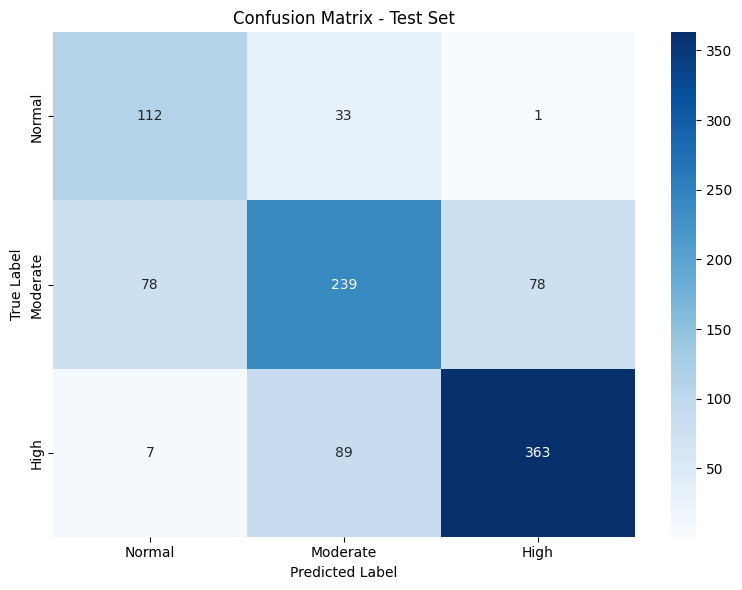


PER-CLASS PERFORMANCE

Normal (0):
  Precision: 0.5685
  Recall:    0.7671
  F1-Score:  0.6531
  Support:   146 samples

Moderate (1):
  Precision: 0.6620
  Recall:    0.6051
  F1-Score:  0.6323
  Support:   395 samples

High (2):
  Precision: 0.8213
  Recall:    0.7908
  F1-Score:  0.8058
  Support:   459 samples


In [19]:
# Model Evaluation on Test Set
print("=" * 60)
print("TEST SET PERFORMANCE")
print("=" * 60)

y_test_pred = model.predict(X_test_scaled)

# For multi-class, specify 'weighted' average
test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred, average='weighted')
test_recall = recall_score(y_test, y_test_pred, average='weighted')
test_f1 = f1_score(y_test, y_test_pred, average='weighted')

print(f"\nOverall Metrics (Weighted Average):")
print(f"Accuracy:  {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall:    {test_recall:.4f}")
print(f"F1-Score:  {test_f1:.4f}")

print("\n" + "=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)
print(classification_report(y_test, y_test_pred, 
                          target_names=['Normal', 'Moderate', 'High']))

# Confusion Matrix
print("\n" + "=" * 60)
print("CONFUSION MATRIX")
print("=" * 60)

from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_test_pred)
print("\nConfusion Matrix:")
print(cm)

# Visualize confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Moderate', 'High'],
            yticklabels=['Normal', 'Moderate', 'High'])
plt.title('Confusion Matrix - Test Set')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('confusion_matrix_test.png', dpi=300, bbox_inches='tight')
plt.show()

# Per-class metrics
print("\n" + "=" * 60)
print("PER-CLASS PERFORMANCE")
print("=" * 60)

from sklearn.metrics import precision_recall_fscore_support

precision_per_class, recall_per_class, f1_per_class, support = \
    precision_recall_fscore_support(y_test, y_test_pred, average=None)

class_names = ['Normal (0)', 'Moderate (1)', 'High (2)']
for i, class_name in enumerate(class_names):
    print(f"\n{class_name}:")
    print(f"  Precision: {precision_per_class[i]:.4f}")
    print(f"  Recall:    {recall_per_class[i]:.4f}")
    print(f"  F1-Score:  {f1_per_class[i]:.4f}")
    print(f"  Support:   {support[i]} samples")

ROC CURVE (One-vs-Rest)


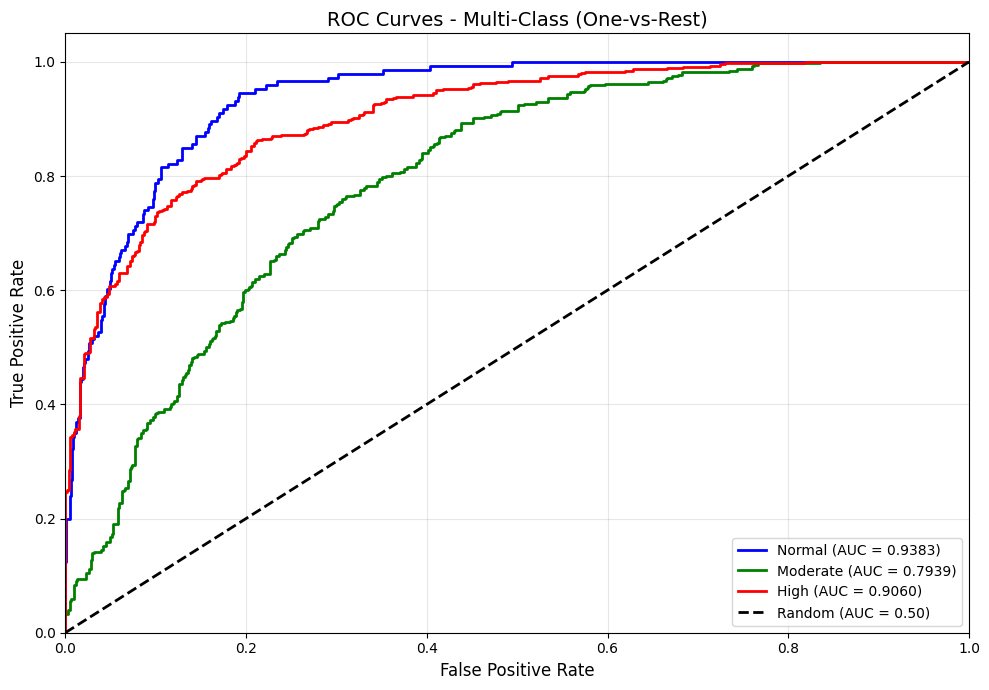


AUC Scores per Class:
Normal    : 0.9383
Moderate  : 0.7939
High      : 0.9060

Macro-Average AUC: 0.8794


In [20]:
# ROC Curve for Multi-Class Classification
print("=" * 60)
print("ROC CURVE (One-vs-Rest)")
print("=" * 60)

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from itertools import cycle

# Get probability predictions for all classes
y_test_proba = model.predict_proba(X_test_scaled)

# Binarize the output for multi-class ROC
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
n_classes = 3

# Compute ROC curve and AUC for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_test_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curves
plt.figure(figsize=(10, 7))
colors = cycle(['blue', 'green', 'red'])
class_names = ['Normal', 'Moderate', 'High']

for i, color, name in zip(range(n_classes), colors, class_names):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'{name} (AUC = {roc_auc[i]:.4f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random (AUC = 0.50)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves - Multi-Class (One-vs-Rest)', fontsize=14)
plt.legend(loc="lower right", fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curve_multiclass.png', dpi=300, bbox_inches='tight')
plt.show()

# Print AUC scores
print("\nAUC Scores per Class:")
for i, name in enumerate(class_names):
    print(f"{name:10s}: {roc_auc[i]:.4f}")
print(f"\nMacro-Average AUC: {sum(roc_auc.values())/n_classes:.4f}")

FEATURE IMPORTANCE

Feature Coefficients (sorted by absolute value):
  Feature  Coefficient  Abs_Coefficient
2  PROBNP    -1.550694         1.550694
5  NFATC3    -1.433845         1.433845
3      EF     1.354962         1.354962
4     GLS    -0.605934         0.605934
0     Age     0.589476         0.589476
1     BMI     0.000351         0.000351


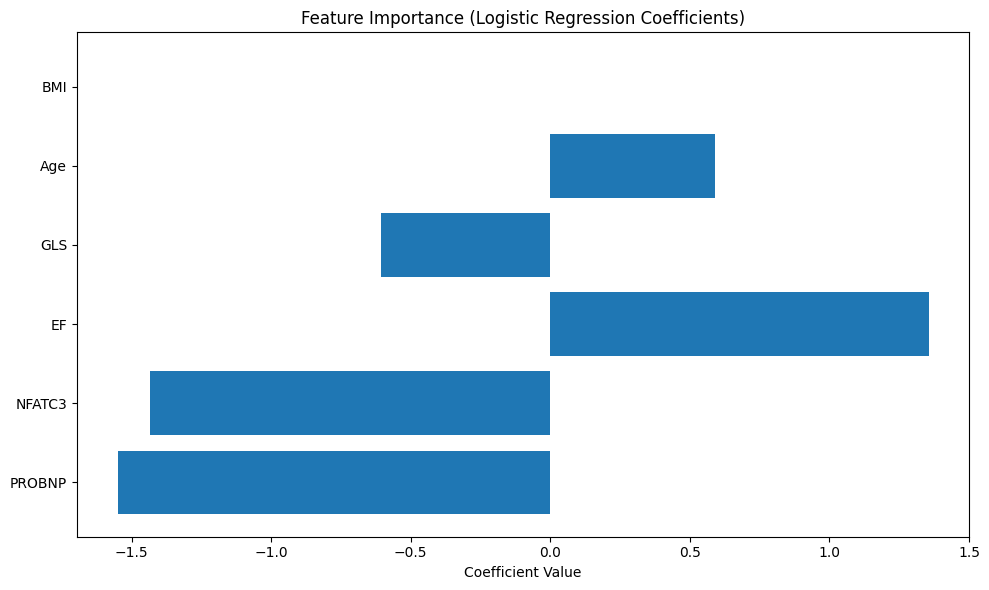

In [21]:
# Feature Importance

print("=" * 60)
print("FEATURE IMPORTANCE")
print("=" * 60)

# Get coefficients
coefficients = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': model.coef_[0]
})
coefficients['Abs_Coefficient'] = abs(coefficients['Coefficient'])
coefficients = coefficients.sort_values('Abs_Coefficient', ascending=False)

print("\nFeature Coefficients (sorted by absolute value):")
print(coefficients)

# Visualize
plt.figure(figsize=(10, 6))
plt.barh(coefficients['Feature'], coefficients['Coefficient'])
plt.xlabel('Coefficient Value')
plt.title('Feature Importance (Logistic Regression Coefficients)')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

In [22]:
# Predict for New Patient
print("=" * 60)
print("PREDICTION FOR NEW PATIENT")
print("=" * 60)

# Patient data 
new_patient = {
    'Age': 28,
    'Gender': 1,
    'BMI': 28,
    'DM': 0,
    'PROBNP': 420,
    'EF': 48,
    'GLS': -10,
    'NFATC3': 1.45
}

# Create DataFrame
new_patient_df = pd.DataFrame([new_patient])
new_patient_df = new_patient_df[feature_cols]

# Scale features
new_patient_scaled = scaler.transform(new_patient_df)

# Predict
prediction = model.predict(new_patient_scaled)[0]
probability = model.predict_proba(new_patient_scaled)[0]

# Class mapping
class_names = {0: 'Normal', 1: 'Moderate', 2: 'High'}
risk_description = {
    0: 'Low Risk - Normal cardiac function',
    1: 'Moderate Risk - Requires monitoring',
    2: 'High Risk - Immediate attention recommended'
}

print("\nPatient Information:")
for key, value in new_patient.items():
    print(f"  {key:12s}: {value}")

print(f"\n{'='*60}")
print(f"PREDICTION RESULT: {class_names[prediction]}")
print(f"{'='*60}")
print(f"\nRisk Level: {risk_description[prediction]}")

print(f"\nClass Probabilities:")
print(f"  Normal (0):   {probability[0]:6.2%}")
print(f"  Moderate (1): {probability[1]:6.2%}")
print(f"  High (2):     {probability[2]:6.2%}")

print(f"\nModel Confidence: {max(probability):.2%}")

# Visual indicator
print("\nRisk Assessment:")
max_bar = 50
print(f"├─ Normal:   {'█' * int(probability[0] * max_bar):<{max_bar}} {probability[0]:6.1%}")
print(f"├─ Moderate: {'█' * int(probability[1] * max_bar):<{max_bar}} {probability[1]:6.1%}")
print(f"└─ High:     {'█' * int(probability[2] * max_bar):<{max_bar}} {probability[2]:6.1%}")

PREDICTION FOR NEW PATIENT

Patient Information:
  Age         : 28
  Gender      : 1
  BMI         : 28
  DM          : 0
  PROBNP      : 420
  EF          : 48
  GLS         : -10
  NFATC3      : 1.45

PREDICTION RESULT: High

Risk Level: High Risk - Immediate attention recommended

Class Probabilities:
  Normal (0):    4.42%
  Moderate (1): 42.75%
  High (2):     52.83%

Model Confidence: 52.83%

Risk Assessment:
├─ Normal:   ██                                                   4.4%
├─ Moderate: █████████████████████                               42.8%
└─ High:     ██████████████████████████                          52.8%


In [23]:
# Model Summary
print("\n" + "=" * 60)
print("MODEL SUMMARY")
print("=" * 60)

# Get top features as a string first
top_features_str = coefficients.head(3)[['Feature', 'Coefficient']].to_string(index=False)

summary = f"""
Model: Logistic Regression
Purpose: Heart Failure Risk Classification
Training Performance:
  - Accuracy:  {train_accuracy:.4f}
  - Precision: {train_precision:.4f}
  - Recall:    {train_recall:.4f}
  - F1-Score:  {train_f1:.4f}

Test Performance:
  - Accuracy:  {test_accuracy:.4f}
  - Precision: {test_precision:.4f}
  - Recall:    {test_recall:.4f}
  - F1-Score:  {test_f1:.4f}

Cross-Validation:
  - Mean Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})

ROC AUC Score (Macro): {sum(roc_auc.values())/len(roc_auc):.4f}

Most Important Features:
{top_features_str}
"""
print(summary)


MODEL SUMMARY

Model: Logistic Regression
Purpose: Heart Failure Risk Classification
Training Performance:
  - Accuracy:  0.7090
  - Precision: 0.7180
  - Recall:    0.7090
  - F1-Score:  0.7102

Test Performance:
  - Accuracy:  0.7140
  - Precision: 0.7215
  - Recall:    0.7140
  - F1-Score:  0.7149

Cross-Validation:
  - Mean Accuracy: 0.7083 (+/- 0.0152)

ROC AUC Score (Macro): 0.8794

Most Important Features:
Feature  Coefficient
 PROBNP    -1.550694
 NFATC3    -1.433845
     EF     1.354962



In [24]:
import joblib

# Save the model
joblib.dump(model, '2.pkl')

# Save the scaler (IMPORTANT - you need this for predictions!)
joblib.dump(scaler, 'scaler.pkl')

print("✓ Model saved as '2.pkl'")
print("✓ Scaler saved as 'scaler.pkl'")

# Load the model later
loaded_model = joblib.load('2.pkl')
loaded_scaler = joblib.load('scaler.pkl')

✓ Model saved as '2.pkl'
✓ Scaler saved as 'scaler.pkl'
